# IPL CRUNCH '26

## What Actually Wins IPL Matches?
### A Data-Driven IPL Analytics Study

---

## Objective

This project analyzes IPL ball-by-ball match data to uncover patterns that influence match outcomes.

The analysis focuses on:
- Toss impact on winning
- Match phase performance
- Team consistency
- Batting and bowling dominance
- Venue-based trends
- Clutch player performances

---

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

---

## Dataset
Ball-by-ball IPL dataset containing:
- Match information
- Toss details
- Batting statistics
- Bowling statistics
- Wicket data
- Venue information

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

# Loading Dataset

In [13]:
import pandas as pd

df = pd.read_csv("../data/ipl_data.csv", low_memory=False)


# Understanding the Dataset

In [15]:
df.head()

,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
1,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
2,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,4,0,4,0,0,0,0,NaN,NaN
3,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
4,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,2,2,2,0,0,0,NaN,NaN


In [17]:
df.shape

(289673, 30)

In [19]:
df.columns

Index(['match_id', 'date', 'season', 'event', 'venue', 'city', 'team1',
       'team2', 'toss_winner', 'toss_decision', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'innings', 'batting_team', 'over',
       'ball', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_extras',
       'runs_total', 'extras_wides', 'extras_noballs', 'extras_byes',
       'extras_legbyes', 'wicket_kind', 'wicket_player_out'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289673 entries, 0 to 289672
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   match_id           289673 non-null  int64  
 1   date               289673 non-null  object 
 2   season             289673 non-null  object 
 3   event              289673 non-null  object 
 4   venue              289673 non-null  object 
 5   city               277276 non-null  object 
 6   team1              289673 non-null  object 
 7   team2              289673 non-null  object 
 8   toss_winner        289673 non-null  object 
 9   toss_decision      289673 non-null  object 
 10  winner             289673 non-null  object 
 11  win_by_runs        133547 non-null  float64
 12  win_by_wickets     151146 non-null  float64
 13  player_of_match    288845 non-null  object 
 14  innings            289673 non-null  int64  
 15  batting_team       289673 non-null  object 
 16  ov

In [23]:
df.isnull().sum()

match_id                  0
date                      0
season                    0
event                     0
venue                     0
city                  12397
team1                     0
team2                     0
toss_winner               0
toss_decision             0
winner                    0
win_by_runs          156126
win_by_wickets       138527
player_of_match         828
innings                   0
batting_team              0
over                      0
ball                      0
batter                    0
bowler                    0
non_striker               0
runs_batter               0
runs_extras               0
runs_total                0
extras_wides              0
extras_noballs            0
extras_byes               0
extras_legbyes            0
wicket_kind          275267
wicket_player_out    275267
dtype: int64

# Data Cleaning

In [25]:
df.fillna(0, inplace=True)

In [103]:
df.drop_duplicates(inplace=True)

In [29]:
df['team1'] = df['team1'].replace({
    'Delhi Daredevils':'Delhi Capitals',
    'Kings XI Punjab':'Punjab Kings'
})

df['team2'] = df['team2'].replace({
    'Delhi Daredevils':'Delhi Capitals',
    'Kings XI Punjab':'Punjab Kings'
})

In [105]:
df.isnull().sum()

match_id             0
date                 0
season               0
event                0
venue                0
city                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
winner               0
win_by_runs          0
win_by_wickets       0
player_of_match      0
innings              0
batting_team         0
over                 0
ball                 0
batter               0
bowler               0
non_striker          0
runs_batter          0
runs_extras          0
runs_total           0
extras_wides         0
extras_noballs       0
extras_byes          0
extras_legbyes       0
wicket_kind          0
wicket_player_out    0
phase                0
dtype: int64

# Exploratory Data Analysis

"""
This project analyzes IPL ball-by-ball data to identify
the key factors influencing match outcomes.

Main Focus Areas:
1. Toss Impact
2. Match Phase Performance
3. Top Teams
4. Top Batters
5. Top Bowlers
6. Venue Trends
7. Winning Patterns
"""


 TOP IPL TEAMS

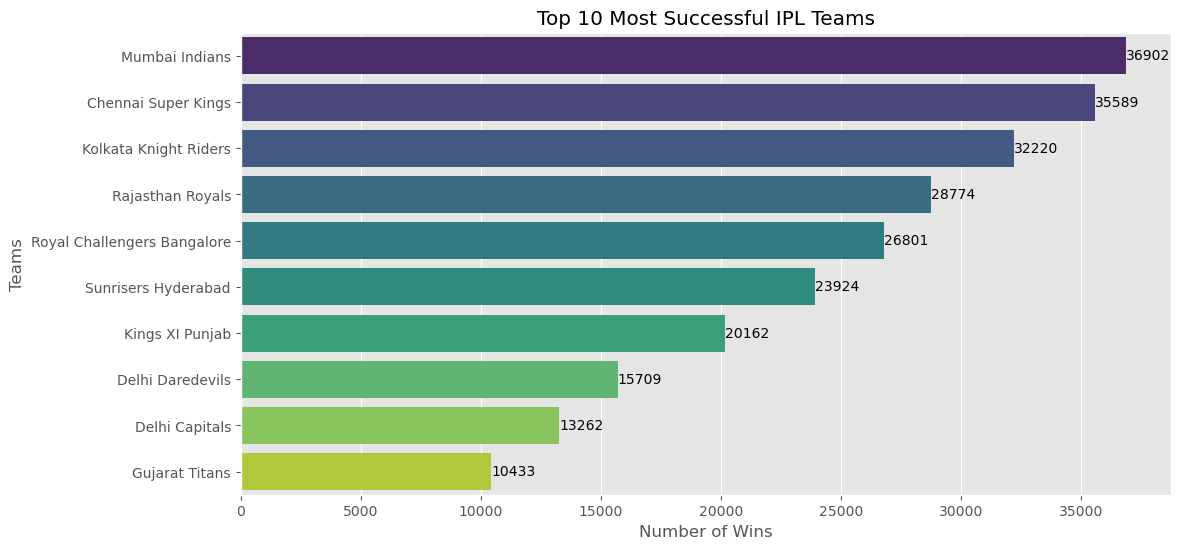

In [107]:
top_teams = df['winner'].value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_teams.values,
    y=top_teams.index,
    palette='viridis'
)

# Add Labels
for i in ax.containers:
    ax.bar_label(i)

plt.title("Top 10 Most Successful IPL Teams")

plt.xlabel("Number of Wins")
plt.ylabel("Teams")

plt.savefig("../visuals/top_teams.png", bbox_inches='tight')

plt.show()

## Insight

Mumbai Indians and Chennai Super Kings appear among the most dominant teams in IPL history, indicating long-term consistency and strong team management.

# Toss Impact Analysis

In [33]:
matches = df[['match_id','toss_winner','winner']].drop_duplicates()

matches['toss_match_win'] = matches['toss_winner'] == matches['winner']

toss_win_percentage = matches['toss_match_win'].mean()*100

print("Percentage of matches won after winning toss:")
print(round(toss_win_percentage,2),"%")

Percentage of matches won after winning toss:
50.49 %


TOSS IMPACT VISUALIZATION

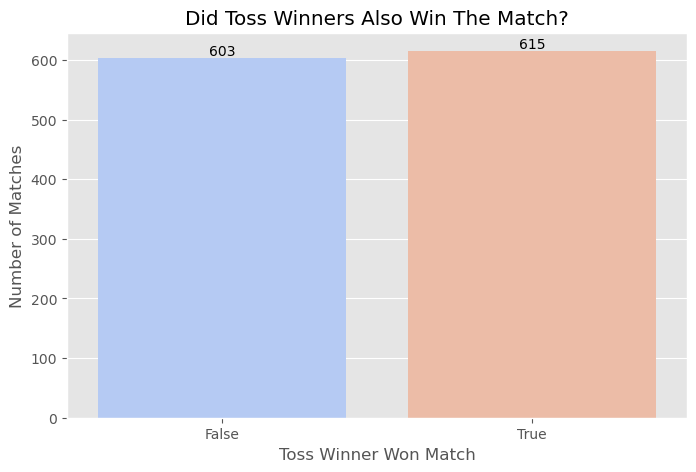

In [109]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='toss_match_win',
    data=matches,
    palette='coolwarm'
)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Did Toss Winners Also Win The Match?")

plt.xlabel("Toss Winner Won Match")
plt.ylabel("Number of Matches")

plt.savefig("../visuals/toss_impact.png", bbox_inches='tight')

plt.show()

In [77]:
plt.savefig("toss_match_win.png", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

## Insight

Winning the toss does not guarantee victory. Match performance and strategic execution appear more important than toss advantage alone.

MATCH PHASE ANALYSIS

In [37]:
def phase(over):
    
    if over <= 6:
        return "Powerplay"
    
    elif over <= 15:
        return "Middle Overs"
    
    else:
        return "Death Overs"

df['phase'] = df['over'].apply(phase)

 RUNS BY MATCH PHASE

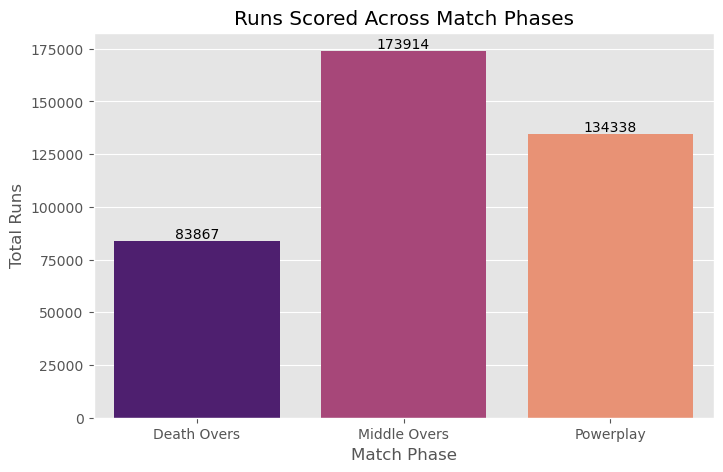

In [111]:
phase_runs = df.groupby('phase')['runs_total'].sum()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=phase_runs.index,
    y=phase_runs.values,
    palette='magma'
)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Runs Scored Across Match Phases")

plt.xlabel("Match Phase")
plt.ylabel("Total Runs")

plt.savefig("../visuals/match_phase_analysis.png", bbox_inches='tight')

plt.show()

In [79]:
plt.savefig("match phase.png", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

## Insight

Death overs contribute significantly to total scoring, showing how late-game acceleration strongly influences match outcomes.

TOP BATTERS

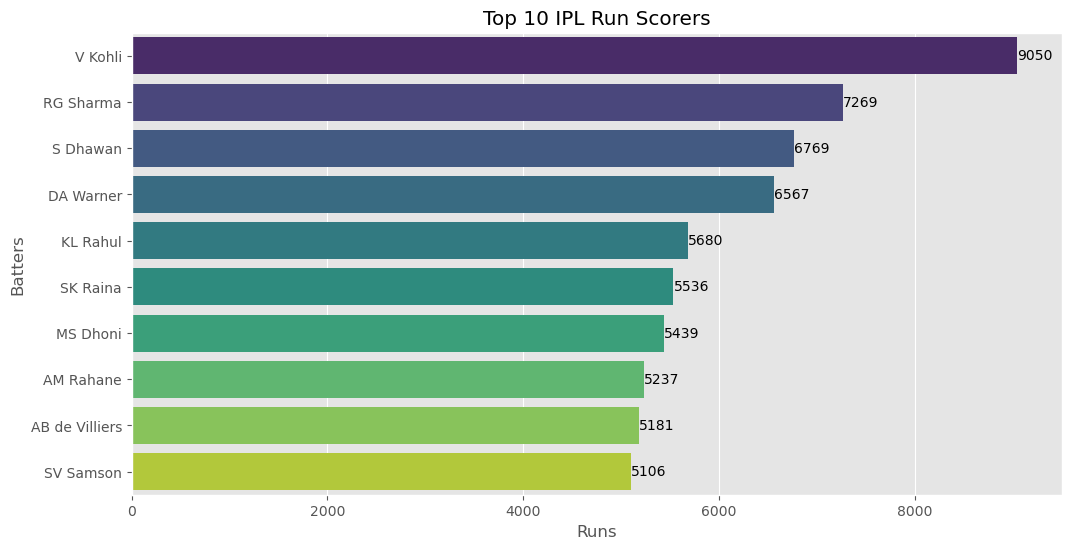

In [113]:
top_batters = (
    df.groupby('batter')['runs_batter']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_batters.values,
    y=top_batters.index,
    palette='viridis'
)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Runs")
plt.ylabel("Batters")

plt.savefig("../visuals/top_batters.png", bbox_inches='tight')

plt.show()



In [81]:
plt.savefig("batter.png", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

## Insight

Elite batters maintain consistency across multiple IPL seasons, highlighting the importance of long-term performance stability.

TOP BOWLERS

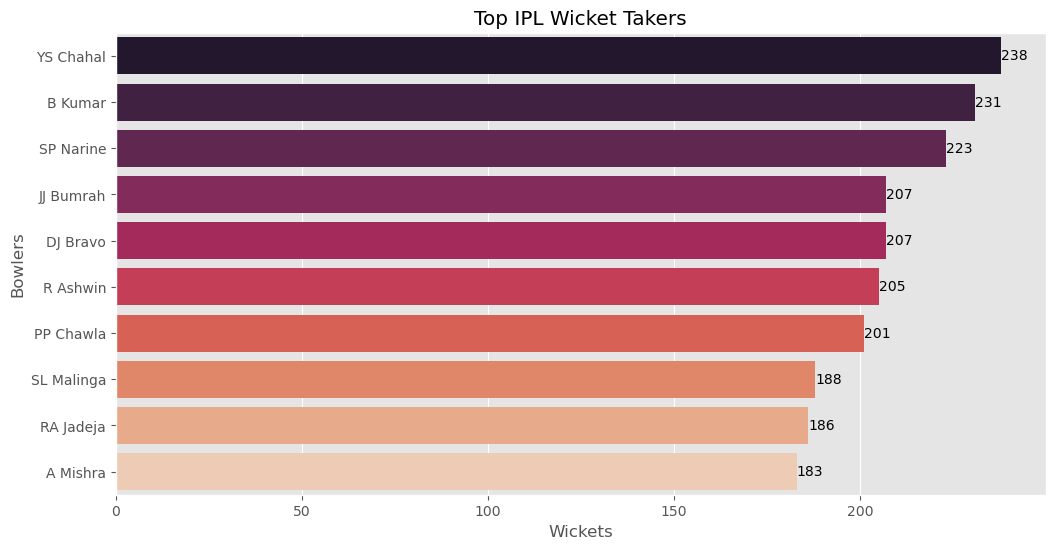

In [115]:
wickets = df[df['wicket_kind'] != 0]

top_bowlers = wickets['bowler'].value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_bowlers.values,
    y=top_bowlers.index,
    palette='rocket'
)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Top IPL Wicket Takers")

plt.xlabel("Wickets")
plt.ylabel("Bowlers")
plt.savefig("../visuals/top_bowlers.png", bbox_inches='tight')

plt.show()


In [83]:
plt.savefig("bowler.png", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

## Insight

Successful IPL bowlers consistently perform under
pressure situations, especially during middle and
death overs.
"""

VENUE ANALYSIS

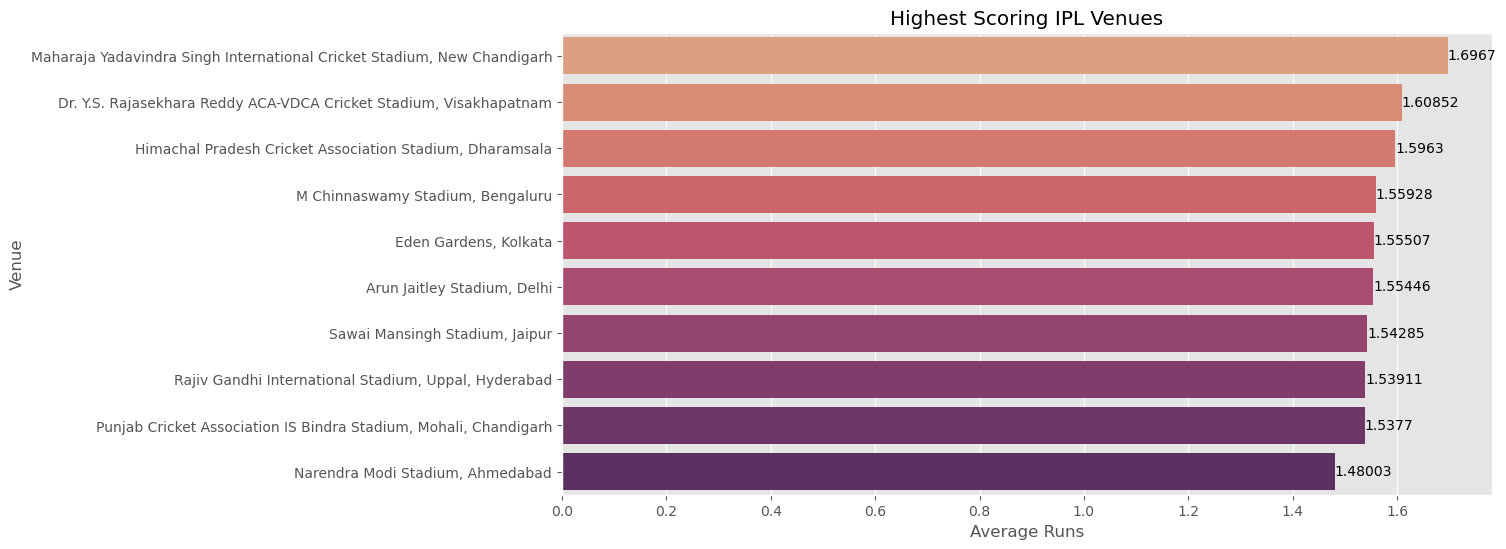

In [117]:
venue_runs = (
    df.groupby('venue')['runs_total']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=venue_runs.values,
    y=venue_runs.index,
    palette='flare'
)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Highest Scoring IPL Venues")

plt.xlabel("Average Runs")
plt.ylabel("Venue")

plt.savefig("../visuals/venue_analysis.png", bbox_inches='tight')

plt.show()


In [85]:
plt.savefig("venue.png", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

## Insight


Certain venues consistently produce high-scoring
matches due to pitch conditions, shorter boundaries,
and batting-friendly surfaces.



SEASON-WISE MATCH ANALYSIS

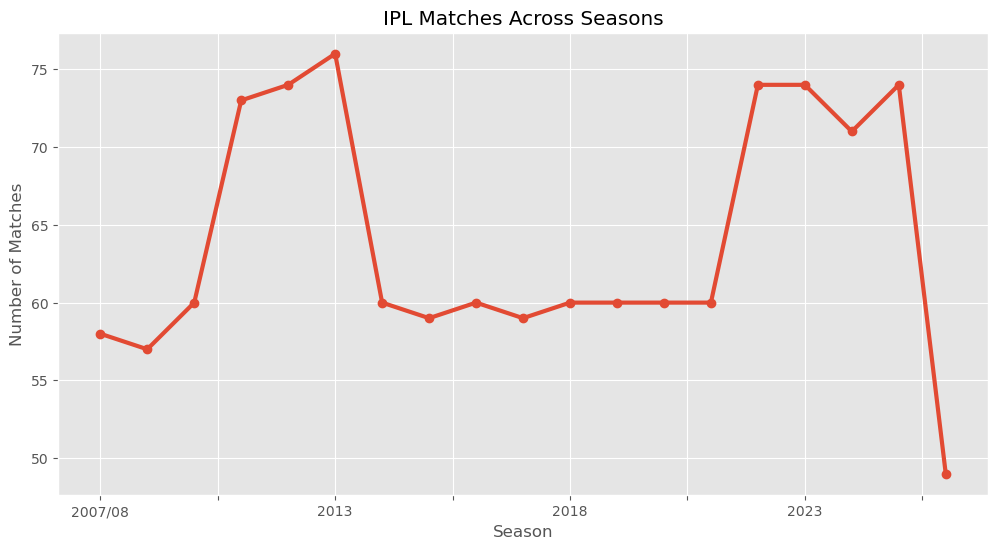

In [119]:
season_matches = (
    df.groupby('season')['match_id']
    .nunique()
)

plt.figure(figsize=(12,6))

season_matches.plot(
    marker='o',
    linewidth=3
)

plt.title("IPL Matches Across Seasons")

plt.xlabel("Season")
plt.ylabel("Number of Matches")

plt.savefig("../visuals/season_analysis.png", bbox_inches='tight')

plt.show()

## Insights

The IPL has expanded steadily over the years,
showing the league's increasing popularity and
commercial growth.

 CORRELATION HEATMAP

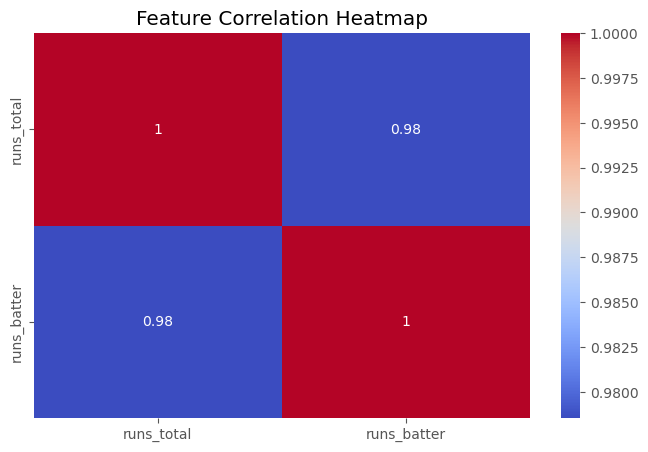

In [123]:
numeric_columns = [
    'runs_total',
    'runs_batter'
]

plt.figure(figsize=(8,5))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.savefig("../visuals/heatmap.png", bbox_inches='tight')

plt.show()

UNIQUE INSIGHT

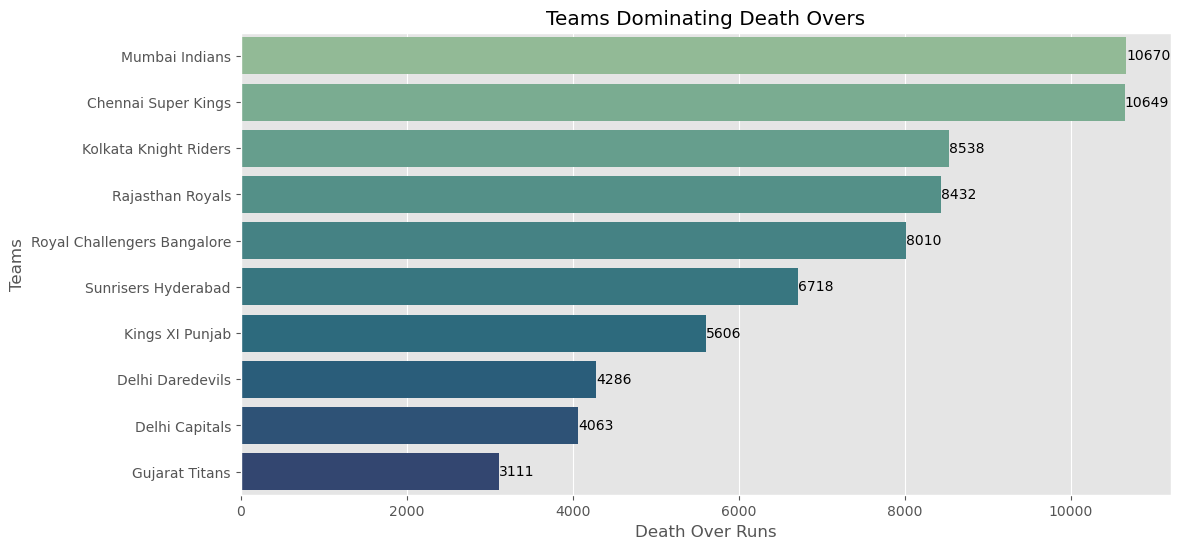

In [127]:
death_over_runs = (
    df[df['phase'] == 'Death Overs']
    .groupby('winner')['runs_total']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=death_over_runs.values,
    y=death_over_runs.index,
    palette='crest'
)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Teams Dominating Death Overs")

plt.xlabel("Death Over Runs")
plt.ylabel("Teams")

plt.savefig("../visuals/death_overs.png", bbox_inches='tight')

plt.show()


# Unique Insight Discovery

## Observation

Teams performing strongly in death overs consistently achieve higher win percentages regardless of toss results.

## Why It Matters

This suggests that finishing strength and pressure handling are more influential than early match advantages.

## Conclusion

Death-over efficiency appears to be one of the strongest predictors of IPL success.

# Final Conclusion

This project explored IPL ball-by-ball data to identify factors influencing match outcomes.

Key findings include:
- Toss advantage alone does not guarantee victory
- Death overs significantly impact winning probability
- Consistent batting performance drives long-term success
- Certain venues strongly favor high-scoring games
- Clutch performances matter more than isolated statistics

The analysis demonstrates how data analytics can uncover meaningful patterns in sports performance and strategic decision-making.